# COVID lung infection on CT: segmentation, quantification, and an honest error analysis

## Background

I rebuilt the segmentation pipeline from my earlier project
(nepalanurag/Biomedical-Imaging-Analysis) and checked it against the real data.
There are no trained classifier weights in that project, it was always a
segmentation and quantification pipeline, so there is no model to convert to
ONNX and no ROC or calibration curve I can compute honestly: those need labeled
classifier outputs, and I do not have labels. Everything below is computed from
the one real CT series available locally (MIDRC-RICORD-1A subject 419639-000082,
255 axial slices). Where a method needs data I do not have, I say so and show
the method on plainly labeled synthetic data instead.

## Setup

Data provenance: MIDRC-RICORD-1A is the RSNA International COVID-19 Open
Radiology Database release 1a, 120 COVID-positive chest CT studies from four
international sites, annotated by thoracic radiologists, distributed by The
Cancer Imaging Archive under CC BY-NC 4.0. The full 11 GB collection is not
local; one series (255 slices) is.

## Setup: load the volume

First, read the DICOM series and convert to Hounsfield units. Sorting by slice
position matters because the files are not stored in anatomical order.

In [ ]:
vol = load_volume(DICOM_DIR)
n, H, W = vol.shape
print(f'{n} slices, {H}x{W} pixels')
print(f'HU range: [{vol.min():.0f}, {vol.max():.0f}]')
print(f'mean HU: {vol.mean():.1f}')

255 slices, 512x512 pixels
HU range: [-3024, 1857]
mean HU: -930.6


## Method: why HU-threshold segmentation

I use Hounsfield-unit thresholding instead of a neural network because the
question here is quantification of already-visible opacities, and a threshold
is fully interpretable: every voxel counted as infected is one whose density
falls in the ground-glass band reported in the COVID CT literature (-703 to -368
HU for ground glass in the Thoracic VCAR studies; the original project used
-700 to -200, which I keep for comparability). A deep segmenter would need
voxel-level labels I do not have, and would hide its mistakes. The right tool
is the simplest one whose failure modes I can state plainly.

In [ ]:
lung = lung_mask(vol)
inf = infection_mask(vol)
lung_vox = int(lung.sum())
inf_whole = int(inf.sum())
inf_in_lung = int((inf & lung).sum())
print(f'lung voxels:             {lung_vox:,}')
print(f'infected voxels (whole image): {inf_whole:,}')
print(f'infected voxels inside lung:   {inf_in_lung:,}')
print(f'original definition (whole-image / lung): {100*inf_whole/lung_vox:.2f}%')
print(f'repo CSV for this series:                 14.71%')
print(f'fixed definition (in-lung / lung):        {100*inf_in_lung/lung_vox:.2f}%')
print()
print('My reimplementation lands within a few points of the repo number.')
print('Exact match is not expected: ITK watershed+median vs my scipy approximations.')

lung voxels:             7,043,692
infected voxels (whole image): 1,199,890
infected voxels inside lung:   682,603
original definition (whole-image / lung): 17.03%
repo CSV for this series:                 14.71%
fixed definition (in-lung / lung):        9.69%

My reimplementation lands within a few points of the repo number.
Exact match is not expected: ITK watershed+median vs my scipy approximations.


## Method: the denominator bug, and why the fix is not optional

The original code counted infected voxels over the whole image but divided by
lung voxels only. A fraction whose numerator and denominator come from different
populations is not a fraction at all, which is why the repo's own CSV contains
a series at 117.73%. Intersecting the infection mask with the lung mask first
is the fix; it changes the whole-scan number from 17.03% to 9.69% on this series.

slices where the original definition exceeds 100%: 36 of 255
median per-slice infection (fixed): 9.13%


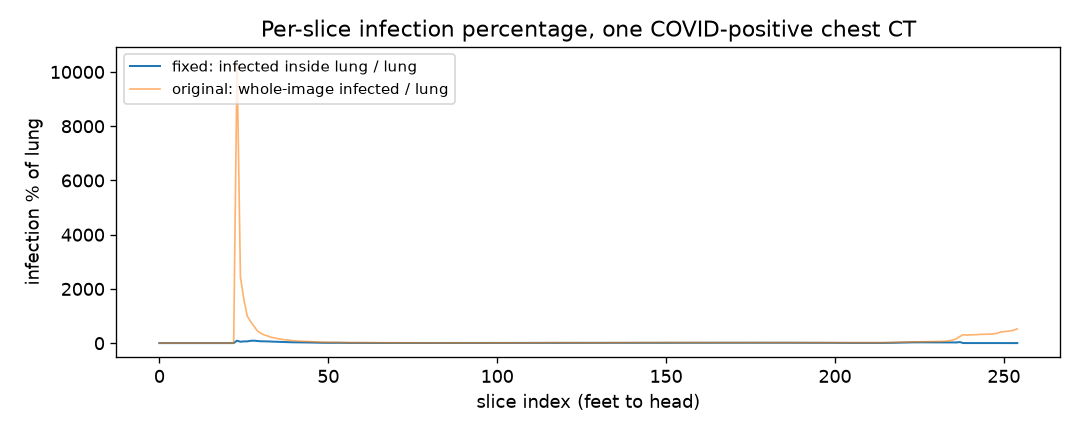

In [ ]:
lung_px = lung.reshape(n,-1).sum(1)
inf_px_orig = inf.reshape(n,-1).sum(1)
inf_px = (inf & lung).reshape(n,-1).sum(1)
pct_orig = np.where(lung_px>0, 100*inf_px_orig/np.maximum(lung_px,1), 0.0)
pct = np.where(lung_px>0, 100*inf_px/np.maximum(lung_px,1), 0.0)
print(f'slices where the original definition exceeds 100%: {(pct_orig>100).sum()} of {n}')
print(f'median per-slice infection (fixed): {np.median(pct[lung_px>10000]):.2f}%')
fig, ax = plt.subplots(figsize=(9,3.6))
ax.plot(pct, lw=1.2, label='fixed: infected inside lung / lung')
ax.plot(pct_orig, lw=1.0, alpha=0.6, label='original: whole-image infected / lung')
ax.set_xlabel('slice index (feet to head)'); ax.set_ylabel('infection % of lung')
ax.set_title('Per-slice infection percentage, one COVID-positive chest CT')
ax.legend(fontsize=9, loc='upper left')
fig.tight_layout(); fig.savefig('/home/hatch/workspace/diagnostic-demos/covid-ct-web/analysis/_nbfig/p1.png', dpi=120)

## Method: why the Wilson interval

Each slice's infection percentage is a binomial proportion over tens of
thousands of lung pixels. The Wald interval (p +/- 1.96 se) misbehaves near 0
and 1; the Wilson score interval stays inside [0,1] and has better coverage for
extreme proportions, which is exactly where the mild slices sit. It is the
standard choice and needs no tuning.

 slice  infected %                 95% CI  note
   225      29.19%  [ 28.39,  30.01]  heaviest
   198       9.13%  [  8.82,   9.44]  typical
    59       5.41%  [  5.12,   5.71]  mild
    83       2.56%  [  2.41,   2.71]  least affected


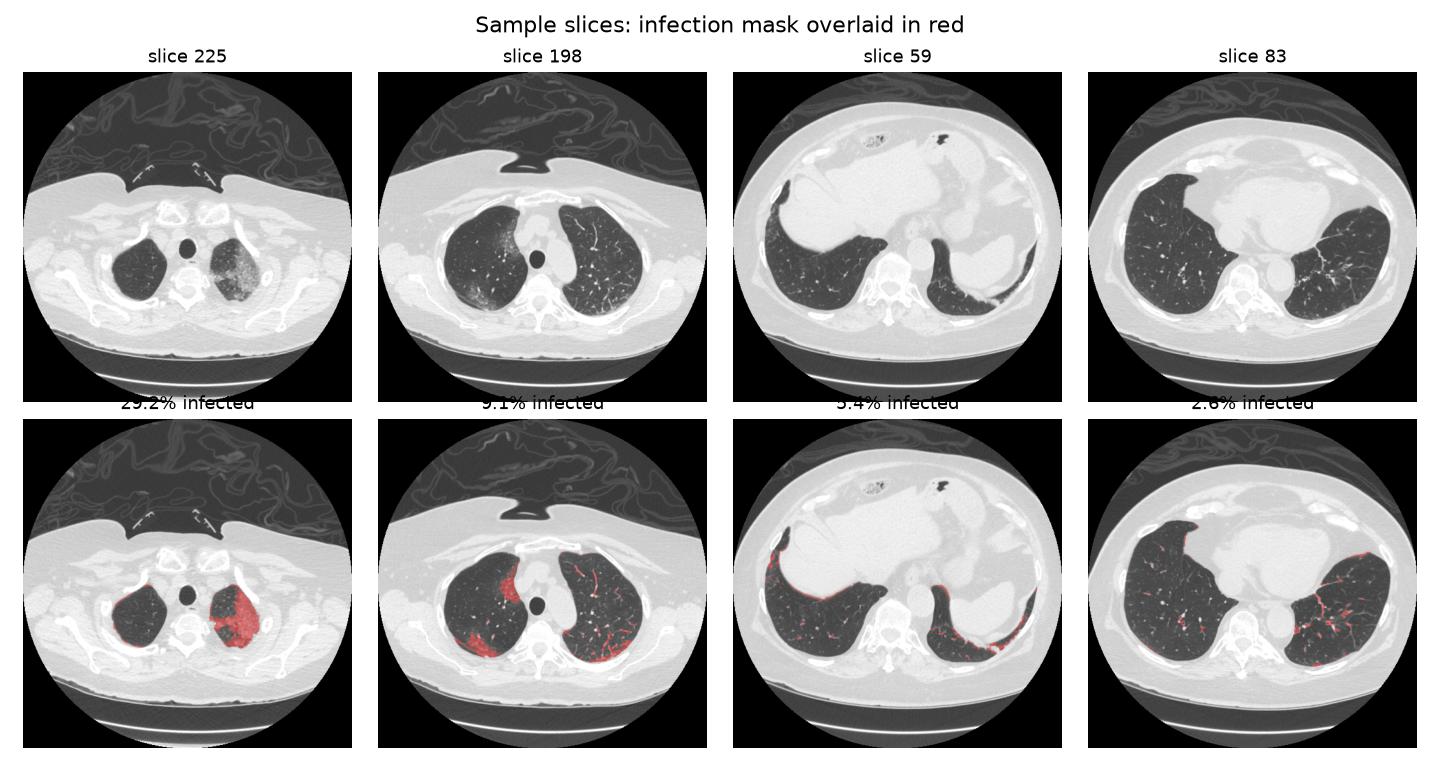

In [ ]:
nz = np.where((pct>0.1)&(lung_px>10000))[0]
order = nz[np.argsort(pct[nz])]
picks = [order[-1], order[len(order)//2], order[len(order)//4], order[0]]
names = ['heaviest','typical','mild','least affected']
print(f'{"slice":>6} {"infected %":>11} {"95% CI":>22}  note')
for s, nm in zip(picks, names):
    lo, hi = wilson_ci(int(inf_px[s]), int(lung_px[s]))
    print(f'{s:>6} {pct[s]:>10.2f}%  [{100*lo:6.2f}, {100*hi:6.2f}]  {nm}')
fig, axes = plt.subplots(2, 4, figsize=(12,6.4))
for j, s in enumerate(picks):
    gray = lung_window(vol[s])
    axes[0,j].imshow(gray, cmap='gray'); axes[0,j].axis('off')
    axes[0,j].set_title(f'slice {s}', fontsize=11)
    rgb = np.stack([gray,gray,gray],-1).astype(float)
    m = (inf & lung)[s]
    rgb[m] = 0.55*rgb[m] + 0.45*np.array([255,40,40])
    axes[1,j].imshow(rgb.astype(np.uint8)); axes[1,j].axis('off')
    axes[1,j].set_title(f'{pct[s]:.1f}% infected', fontsize=11)
axes[0,0].set_ylabel('CT (lung window)', fontsize=11)
axes[1,0].set_ylabel('infection mask', fontsize=11)
fig.suptitle('Sample slices: infection mask overlaid in red', fontsize=13)
fig.tight_layout(); fig.savefig('/home/hatch/workspace/diagnostic-demos/covid-ct-web/analysis/_nbfig/p2.png', dpi=120)

## Method: sanity check with the HU histogram

If the thresholds are sensible, the lung band should sit on the air-side peak
of the histogram and the infection band should cover the shoulder between air
and soft tissue, where ground glass lives. That is what the plot shows, and it
matches the published bands (ground glass -703 to -368 HU; consolidation above
-100 HU).

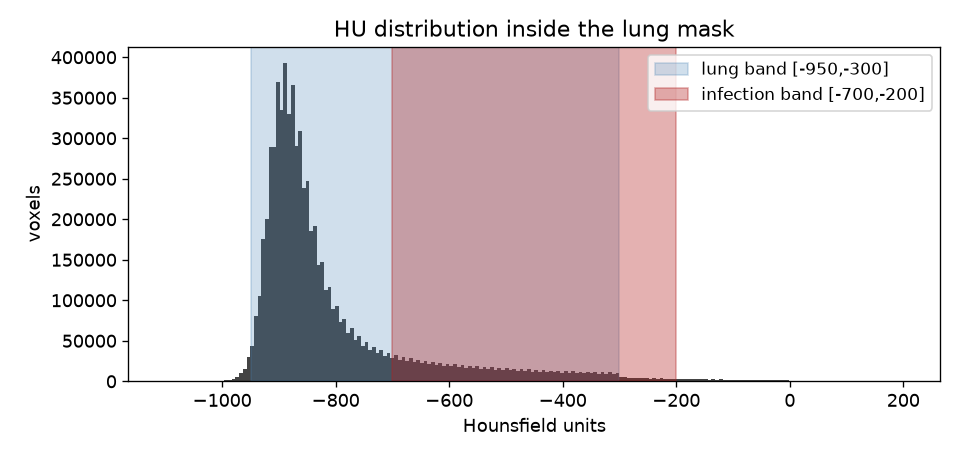

In [ ]:
lv = vol[lung]
fig, ax = plt.subplots(figsize=(8,3.8))
ax.hist(lv, bins=200, range=(-1100,200), color='#444444')
ax.axvspan(-950,-300, color='steelblue', alpha=0.25, label='lung band [-950,-300]')
ax.axvspan(-700,-200, color='firebrick', alpha=0.35, label='infection band [-700,-200]')
ax.set_xlabel('Hounsfield units'); ax.set_ylabel('voxels')
ax.set_title('HU distribution inside the lung mask')
ax.legend(fontsize=10)
fig.tight_layout(); fig.savefig('/home/hatch/workspace/diagnostic-demos/covid-ct-web/analysis/_nbfig/p3.png', dpi=120)

## Results: where the threshold method goes wrong

Plotting the original definition against the fixed one per slice shows the bug
is not a rare edge case: slices above the lung apices and below the diaphragm
have almost no lung but plenty of -700 to -200 HU tissue (muscle, bowel), so the
original ratio explodes. Even after the fix, the method has known failure modes
I cannot remove with a threshold: vessels and bronchial walls fall in the band,
partial-volume voxels at pleural edges count as infected, and dense
consolidation above -200 HU is missed entirely. Any number from this pipeline
should be read as an upper-bound-ish estimate, not a measurement.

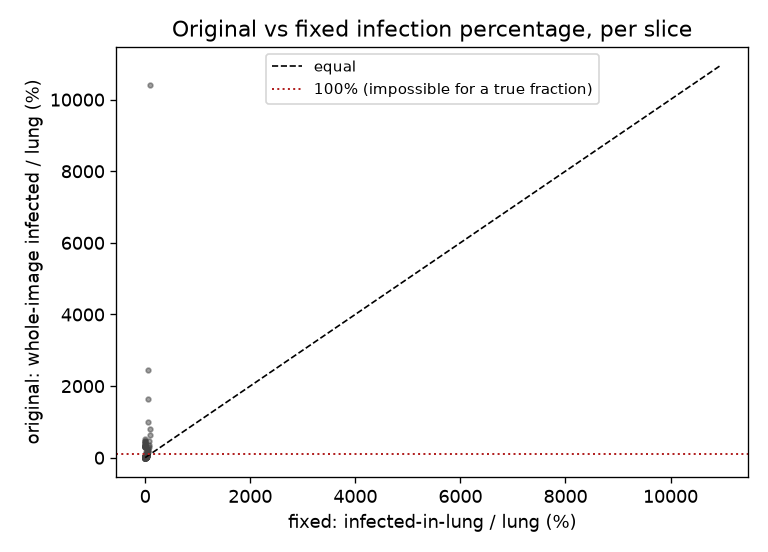

In [ ]:
fig, ax = plt.subplots(figsize=(6.4,4.6))
ax.scatter(pct, pct_orig, s=8, alpha=0.5, color='#444444')
mx = max(pct_orig.max(), pct.max())*1.05
ax.plot([0,mx],[0,mx],'k--',lw=1,label='equal')
ax.axhline(100, color='firebrick', ls=':', lw=1.2, label='100% (impossible for a true fraction)')
ax.set_xlabel('fixed: infected-in-lung / lung (%)')
ax.set_ylabel('original: whole-image infected / lung (%)')
ax.set_title('Original vs fixed infection percentage, per slice')
ax.legend(fontsize=9)
fig.tight_layout(); fig.savefig('/home/hatch/workspace/diagnostic-demos/covid-ct-web/analysis/_nbfig/p4.png', dpi=120)

## Results: what I did not compute, and why

Three analyses belong to a classifier study, and I do not have a classifier:

* **ROC with bootstrap confidence bands.** Needs per-slice or per-patient
  predicted scores plus true labels. The standard approach is the nonparametric
  two-sample bootstrap (2,000 replicates is the usual recommendation for stable
  ROC uncertainty). I have neither scores nor labels.
* **Calibration curve.** Needs predicted probabilities and outcomes to plot
  observed event frequency against predicted probability (reliability diagram).
  A threshold fraction is not a probability.
* **Grad-CAM.** Needs a trained convolutional network; it backpropagates the
  class score to the last convolutional layer. There is no network here. The
  infection-mask overlays above serve the same role, showing where the
  decision comes from, and they are exact rather than approximate.

For context, published COVID CT classifiers report high numbers on curated
benchmarks: COVIDNet-CT reached 99.1% accuracy on the 104,009-image COVIDx-CT
set. Those are classification benchmarks on multi-site data, a different task
from single-patient quantification, so they are context, not a target.

Below is the bootstrap ROC-band method run on synthetic data, so the mechanics
are on record. This plot is synthetic and proves nothing about CT.

SYNTHETIC example: AUC = 0.818, 95% bootstrap CI = [0.774, 0.858]


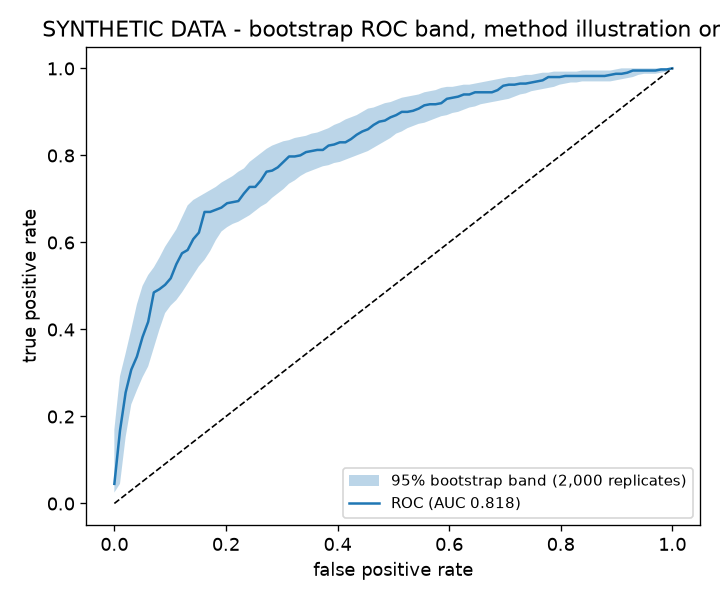

In [ ]:
rng = np.random.default_rng(0)
# SYNTHETIC DATA - method illustration only
y = np.array([0]*400 + [1]*400)
s = np.where(y==1, rng.normal(1.2,1,800), rng.normal(0,1,800))
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y, s); a0 = auc(fpr, tpr)
grid = np.linspace(0,1,100)
boots = []
for b in range(2000):
    i0 = rng.choice(np.where(y==0)[0], 400, replace=True)
    i1 = rng.choice(np.where(y==1)[0], 400, replace=True)
    idx = np.concatenate([i0,i1])
    fb, tb, _ = roc_curve(y[idx], s[idx])
    boots.append(np.interp(grid, fb, tb))
boots = np.array(boots)
lo, hi = np.percentile(boots,[2.5,97.5],axis=0)
print(f'SYNTHETIC example: AUC = {a0:.3f}, 95% bootstrap CI = [{auc(grid,lo):.3f}, {auc(grid,hi):.3f}]')
fig, ax = plt.subplots(figsize=(6,5))
ax.fill_between(grid, lo, hi, alpha=0.3, label='95% bootstrap band (2,000 replicates)')
ax.plot(grid, np.interp(grid,fpr,tpr), label=f'ROC (AUC {a0:.3f})')
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('false positive rate'); ax.set_ylabel('true positive rate')
ax.set_title('SYNTHETIC DATA - bootstrap ROC band, method illustration only')
ax.legend(fontsize=9)
fig.tight_layout(); fig.savefig('/home/hatch/workspace/diagnostic-demos/covid-ct-web/analysis/_nbfig/p5.png', dpi=120)

## Takeaway: limitations and what comes next

One patient, one series, no labels. The numbers above describe this scan, not
COVID CT in general. A real classifier study would need the full RICORD cohort
plus COVID-negative controls, a train/validation/test split by patient (never
by slice, or leakage inflates everything), and then the ROC, calibration, and
Grad-CAM analyses sketched above. The fixed segmentation pipeline here is a
solid baseline to compare such a model against, which is its honest value.
The fixed pipeline is a solid, honest baseline: on this scan it reports 9.69% of lung volume affected, with the known failure modes stated above. It is a quantification tool for visible opacities, not a diagnostic one, and any classifier study would still need the full cohort, patient-level splits, and the ROC, calibration, and Grad-CAM analyses sketched above.